In [2]:
##Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
##Create Sample Dataset
np.random.seed(42)

departments = ['Computer Science', 'Mathematics', 'Physics', 'Statistics']
semesters = [1, 2, 3, 4, 5, 6]

data = {
    'Student ID': range(1, 51),
    'Student Name': [f'Student_{i}' for i in range(1, 51)],
    'Department': np.random.choice(departments, 50),
    'Attendance Percentage': np.random.randint(60, 101, 50),
    'Marks Obtained': np.random.randint(40, 101, 50),
    'Semester': np.random.choice(semesters, 50)
}

df = pd.DataFrame(data)

df.head()

,Student ID,Student Name,Department,Attendance Percentage,Marks Obtained,Semester
0,1,Student_1,Physics,62,46,3
1,2,Student_2,Statistics,96,48,1
2,3,Student_3,Computer Science,66,63,2
3,4,Student_4,Physics,80,40,2
4,5,Student_5,Physics,68,83,4


In [4]:
# Save dataset as CSV file
df.to_csv("student_performance.csv", index=False)

DATA **EXPLORATION**

In [5]:
# Display the first five rows of the dataset
df.head()

,Student ID,Student Name,Department,Attendance Percentage,Marks Obtained,Semester
0,1,Student_1,Physics,62,46,3
1,2,Student_2,Statistics,96,48,1
2,3,Student_3,Computer Science,66,63,2
3,4,Student_4,Physics,80,40,2
4,5,Student_5,Physics,68,83,4


In [6]:
# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student ID             50 non-null     int64 
 1   Student Name           50 non-null     object
 2   Department             50 non-null     object
 3   Attendance Percentage  50 non-null     int64 
 4   Marks Obtained         50 non-null     int64 
 5   Semester               50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


In [7]:
# Check for missing values in each column
df.isnull().sum()

,0
Student ID,0
Student Name,0
Department,0
Attendance Percentage,0
Marks Obtained,0
Semester,0


In [8]:
#descriptive statistics for numerical columns
df.describe()

,Student ID,Attendance Percentage,Marks Obtained,Semester
count,50.00000,50.000000,50.000000,50.00000
mean,25.50000,78.480000,65.980000,3.62000
std,14.57738,11.804945,16.998787,1.70102
min,1.00000,60.000000,40.000000,1.00000
25%,13.25000,68.000000,48.500000,2.00000
50%,25.50000,77.000000,66.500000,4.00000
75%,37.75000,86.500000,78.000000,5.00000
max,50.00000,100.000000,98.000000,6.00000


DATA **ANALYSIS**

In [9]:
# Calculate average marks obtained by students

average_marks = df['Marks Obtained'].mean()

print("Average Marks:", round(average_marks, 2))

Average Marks: 65.98


In [10]:
# Find the highest marks in the dataset

highest_marks = df['Marks Obtained'].max()

print("Highest Marks:", highest_marks)

Highest Marks: 98


In [11]:
# Find the lowest marks in the dataset

lowest_marks = df['Marks Obtained'].min()

print("Lowest Marks:", lowest_marks)

Lowest Marks: 40


In [12]:
# Calculate average marks for each department

dept_performance = df.groupby('Department')['Marks Obtained'].mean()

dept_performance

,Marks Obtained
Department,
Computer Science,58.000000
Mathematics,68.090909
Physics,72.000000
Statistics,64.625000


In [13]:
# Calculate correlation between attendance and marks

correlation = df['Attendance Percentage'].corr(df['Marks Obtained'])

print("Correlation:", round(correlation, 3))

Correlation: -0.004


In [14]:
# Display top 10 students based on marks obtained

top10 = df.nlargest(10, 'Marks Obtained')

top10[['Student ID',
       'Student Name',
       'Department',
       'Marks Obtained']]

,Student ID,Student Name,Department,Marks Obtained
14,15,Student_15,Statistics,98
18,19,Student_19,Statistics,97
28,29,Student_29,Statistics,94
47,48,Student_48,Physics,94
8,9,Student_9,Physics,90
27,28,Student_28,Mathematics,87
41,42,Student_42,Physics,86
4,5,Student_5,Physics,83
33,34,Student_34,Mathematics,83
16,17,Student_17,Statistics,81


DATA **VISUALIZATION**

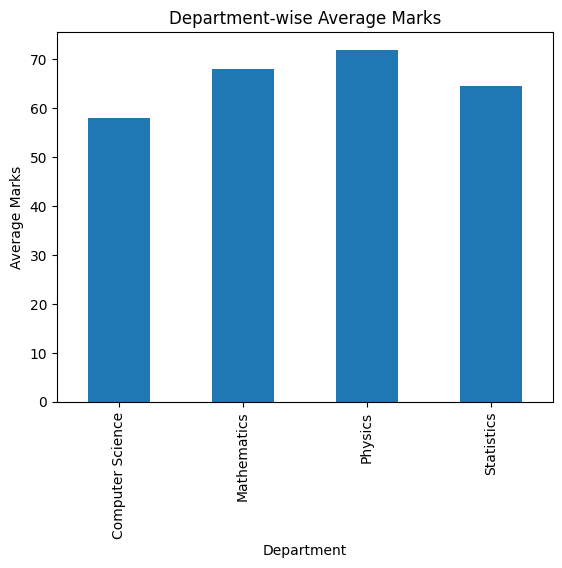

In [15]:
# Create a bar chart showing average marks by department

dept_performance.plot(kind='bar')

plt.title('Department-wise Average Marks')
plt.xlabel('Department')
plt.ylabel('Average Marks')

plt.show()

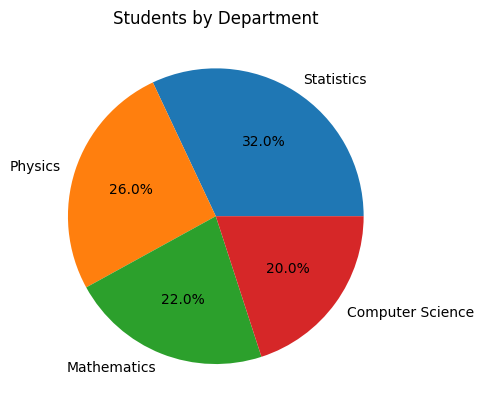

In [16]:
# Create a pie chart showing student distribution by department

dept_counts = df['Department'].value_counts()

plt.pie(
    dept_counts,
    labels=dept_counts.index,
    autopct='%1.1f%%'
)

plt.title('Students by Department')

plt.show()

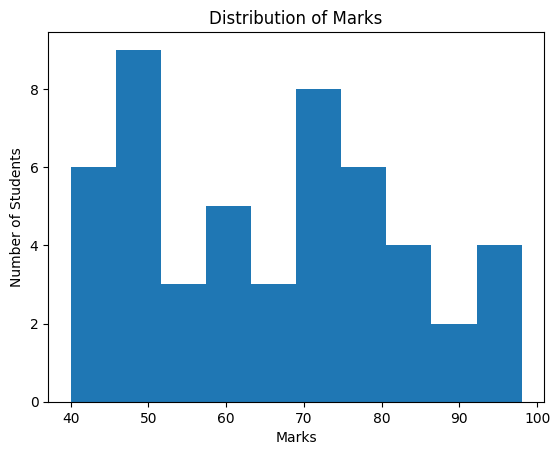

In [17]:
# Create a histogram showing marks distribution

plt.hist(df['Marks Obtained'], bins=10)

plt.title('Distribution of Marks')
plt.xlabel('Marks')
plt.ylabel('Number of Students')

plt.show()

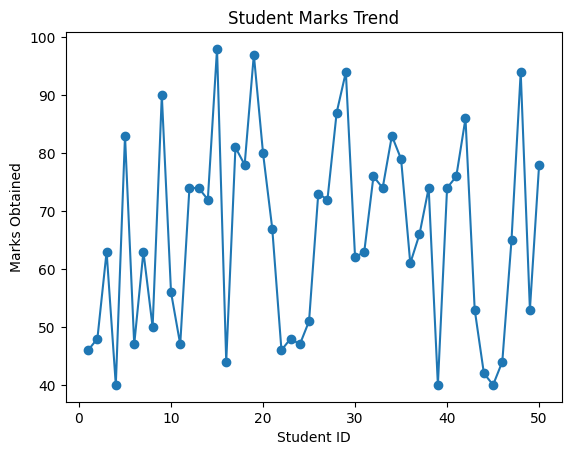

In [18]:
# Create a line chart showing marks trend by student ID

sorted_df = df.sort_values('Student ID')

plt.plot(
    sorted_df['Student ID'],
    sorted_df['Marks Obtained'],
    marker='o'
)

plt.title('Student Marks Trend')
plt.xlabel('Student ID')
plt.ylabel('Marks Obtained')

plt.show()